In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

!{sys.executable} -m pip install pyarrow

from pyspark.sql import SparkSession
from pyspark.sql.window import Window

spark = SparkSession.builder.getOrCreate()


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/01 18:45:14 WARN Utils: Your hostname, AS-MAC-1343s-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.20.3.51 instead (on interface en0)
26/07/01 18:45:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/01 18:45:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 52129)
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/socketserver.py", line 755, in __init__
    self.handle()
  File "/opt/homebrew/lib/python3.11/site-packages/py

In [2]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("weekly_modelling_dataset.csv")
)

df.printSchema()
df.show(5)

root
 |-- week_start: date (nullable = true)
 |-- week_id: integer (nullable = true)
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- weekly_volume: double (nullable = true)
 |-- weekly_value: double (nullable = true)
 |-- weekly_avg_price: double (nullable = true)
 |-- regular_price: double (nullable = true)
 |-- price_drop_pct: double (nullable = true)
 |-- promo_flag: integer (nullable = true)
 |-- discount_bucket: string (nullable = true)
 |-- holiday_flag: integer (nullable = true)
 |-- holiday_window_flag: integer (nullable = true)
 |-- holiday_period: string (nullable = true)

+----------+-------+---------------+-----------------+-------------+------------+----------------+-------------+--------------+----------+---------------+------------+-------------------+--------------+
|week_start|week_id|masked_store_id|masked_product_id|weekly_volume|weekly_value|weekly_avg_price|regular_price|price_drop_pct|promo_flag|discount_bucke

In [3]:
#checking if the grain is actually unique
from pyspark.sql.functions import count

grain_check = (
    df.groupBy(
        "masked_store_id",
        "masked_product_id",
        "week_start"
    )
    .count()
    .filter("count > 1")
)

print("Duplicate grain rows:", grain_check.count())

Duplicate grain rows: 0


In [4]:
from pyspark.sql.functions import min, max

df.select(
    min("week_start"),
    max("week_start")
).show()

+---------------+---------------+
|min(week_start)|max(week_start)|
+---------------+---------------+
|     2024-12-30|     2026-04-27|
+---------------+---------------+



In [5]:
sample = (
    df.filter(
        (df.masked_store_id == 103) &
        (df.masked_product_id == 4338)
    )
    .orderBy("week_start")
)

sample.show(70, False)

+----------+-------+---------------+-----------------+-------------+------------------+-----------------+-------------+------------------+----------+---------------+------------+-------------------+--------------+
|week_start|week_id|masked_store_id|masked_product_id|weekly_volume|weekly_value      |weekly_avg_price |regular_price|price_drop_pct    |promo_flag|discount_bucket|holiday_flag|holiday_window_flag|holiday_period|
+----------+-------+---------------+-----------------+-------------+------------------+-----------------+-------------+------------------+----------+---------------+------------+-------------------+--------------+
|2025-08-04|32     |103            |4338             |0.0          |0.0               |NULL             |NULL         |NULL              |0         |No Price Data  |0           |NULL               |NORMAL        |
|2025-08-11|33     |103            |4338             |0.0          |0.0               |NULL             |NULL         |NULL              |0     

In [6]:
df.select(
    "masked_store_id",
    "masked_product_id"
).distinct().count()

7720

In [7]:
df.groupBy(
    "masked_store_id",
    "masked_product_id"
).count().summary().show()

26/07/01 18:45:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+
|summary|   masked_store_id| masked_product_id|             count|
+-------+------------------+------------------+------------------+
|  count|              7720|              7720|              7720|
|   mean| 571.6366580310881| 5769.666968911917| 61.87720207253886|
| stddev|272.31454283204494|2543.1853111762025|15.453240476301131|
|    min|               100|              1124|                 1|
|    25%|               325|              3929|                62|
|    50%|               600|              5114|                70|
|    75%|               814|              7618|                70|
|    max|               999|              9824|                70|
+-------+------------------+------------------+------------------+



In [8]:
from pyspark.sql.functions import count

series_lengths = (
    df.groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .agg(count("*").alias("history_length"))
)

series_lengths.groupBy("history_length").count().orderBy("history_length").show(100)

+--------------+-----+
|history_length|count|
+--------------+-----+
|             1|    4|
|             2|   13|
|             3|   14|
|             4|   25|
|             5|   14|
|             6|   10|
|             7|    7|
|             8|    6|
|             9|   15|
|            10|   16|
|            11|    7|
|            12|   16|
|            13|   18|
|            14|   14|
|            15|    2|
|            16|    3|
|            17|    6|
|            18|    9|
|            19|   10|
|            20|    6|
|            21|    6|
|            22|    4|
|            23|   10|
|            24|   89|
|            25|   61|
|            26|    5|
|            27|   36|
|            28|    2|
|            29|    2|
|            30|    3|
|            31|  285|
|            32|    3|
|            33|    9|
|            34|   17|
|            35|   46|
|            36|   14|
|            37|   15|
|            38|   14|
|            39|  312|
|            40|   30|
|          

In [9]:
series_lengths = (
    df.groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .count()
)

for window in [4, 8, 13, 26]:
    n = series_lengths.filter(f"count >= {window}").count()
    print(f"MA({window}): {n}")

MA(4): 7689
MA(8): 7633
MA(13): 7573
MA(26): 7335


# Forecast Evaluation Methodology

## Objective

Forecast next week's weekly_volume for each
(store, product) series.

## Granularity

Each row represents:

(masked_store_id, masked_product_id, week_start)

## Train-Test Split

Training Period:
Week 1 - Week 56

Testing Period:
Week 57 - Week 70

## Evaluation Strategy

A rolling-origin (walk-forward) forecasting strategy is used.

For each test week:

Forecast Week 57
→ Use history through Week 56

Forecast Week 58
→ Use history through Week 57

Forecast Week 59
→ Use history through Week 58

...

Forecast Week 70
→ Use history through Week 69

This ensures forecasts only use information available at prediction time.

## Metrics

- MAE
- RMSE
- Mean Residual

In [10]:
sample = (
    df.filter(
        (df.masked_store_id == 103) &
        (df.masked_product_id == 4338)
    )
    .orderBy("week_start")
)

sample_pd = sample.toPandas()

sample_pd[[
    "week_id",
    "week_start",
    "weekly_volume"
]]

,week_id,week_start,weekly_volume
0,32,2025-08-04,0.0
1,33,2025-08-11,0.0
2,34,2025-08-18,2.0
3,35,2025-08-25,0.0
4,36,2025-09-01,2.0
5,37,2025-09-08,1.0
6,38,2025-09-15,4.0
7,39,2025-09-22,1.0
8,40,2025-09-29,1.0
9,41,2025-10-06,0.0


# Moving Average (Window = 4)

Forecast(t)

= Average of previous 4 observed weeks

Example:

Week 57 forecast
= average(Weeks 53-56)

Week 58 forecast
= average(Weeks 54-57)

Week 59 forecast
= average(Weeks 55-58)

The forecast updates every week as new actual demand becomes available.

In [11]:
forecasts = []

for target_week in range(57, 71):

    history = sample_pd.loc[
        sample_pd["week_id"] < target_week,
        "weekly_volume"
    ]

    if len(history) < 4:
        continue

    forecast = history.tail(4).mean()

    actual = sample_pd.loc[
        sample_pd["week_id"] == target_week,
        "weekly_volume"
    ].iloc[0]

    forecasts.append({
        "week_id": target_week,
        "actual": actual,
        "forecast": forecast
    })

forecast_df = pd.DataFrame(forecasts)

forecast_df

,week_id,actual,forecast
0,57,2.0,1.50
1,58,0.0,2.00
2,59,2.0,1.75
3,60,0.0,1.75
4,61,0.0,1.00
5,62,0.0,0.50
6,63,0.0,0.50
7,64,2.0,0.00
8,65,0.0,0.50
9,66,3.0,0.50


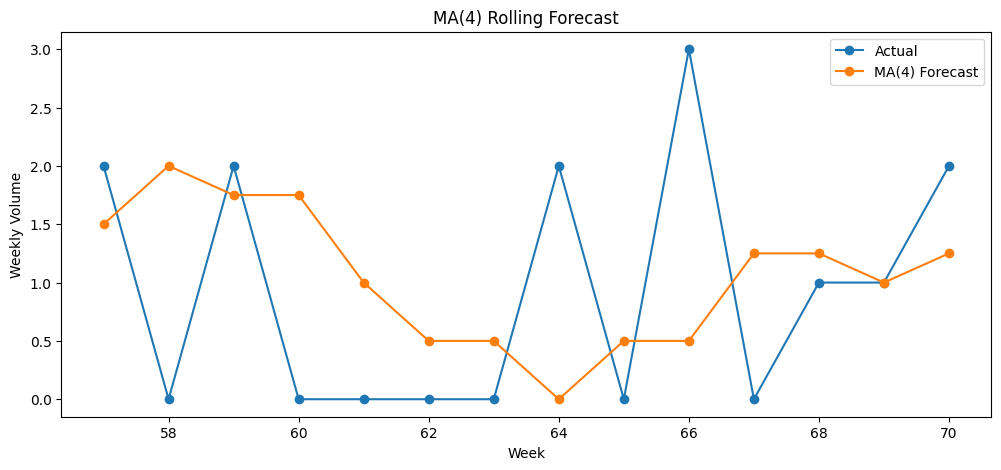

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast_df["week_id"],
    forecast_df["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_df["week_id"],
    forecast_df["forecast"],
    marker="o",
    label="MA(4) Forecast"
)

plt.xlabel("Week")
plt.ylabel("Weekly Volume")
plt.title("MA(4) Rolling Forecast")
plt.legend()

plt.show()

# Moving Average

In [13]:
#Generic MA function
import pyspark.sql.functions as F
from pyspark.sql.window import Window

def add_moving_average_forecast(df, window_size):

    ma_window = (
        Window
        .partitionBy(
            "masked_store_id",
            "masked_product_id"
        )
        .orderBy("week_start")
        .rowsBetween(-window_size, -1)
    )

    return (
        df.withColumn(
            f"ma_{window_size}_forecast",
            F.avg("weekly_volume").over(ma_window)
        )
    )

In [14]:
#Creating forecast 
import time

start = time.perf_counter()

ma_df = df

for w in [4, 8, 13, 26]:
    ma_df = add_moving_average_forecast(
        ma_df,
        window_size=w
    )

ma_df.count()      # Force Spark execution

ma_runtime = time.perf_counter() - start

print(f"MA Runtime: {ma_runtime:.3f} sec")

ma_df.printSchema()

MA Runtime: 0.166 sec
root
 |-- week_start: date (nullable = true)
 |-- week_id: integer (nullable = true)
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- weekly_volume: double (nullable = true)
 |-- weekly_value: double (nullable = true)
 |-- weekly_avg_price: double (nullable = true)
 |-- regular_price: double (nullable = true)
 |-- price_drop_pct: double (nullable = true)
 |-- promo_flag: integer (nullable = true)
 |-- discount_bucket: string (nullable = true)
 |-- holiday_flag: integer (nullable = true)
 |-- holiday_window_flag: integer (nullable = true)
 |-- holiday_period: string (nullable = true)
 |-- ma_4_forecast: double (nullable = true)
 |-- ma_8_forecast: double (nullable = true)
 |-- ma_13_forecast: double (nullable = true)
 |-- ma_26_forecast: double (nullable = true)



In [15]:
ma_df.printSchema()

root
 |-- week_start: date (nullable = true)
 |-- week_id: integer (nullable = true)
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- weekly_volume: double (nullable = true)
 |-- weekly_value: double (nullable = true)
 |-- weekly_avg_price: double (nullable = true)
 |-- regular_price: double (nullable = true)
 |-- price_drop_pct: double (nullable = true)
 |-- promo_flag: integer (nullable = true)
 |-- discount_bucket: string (nullable = true)
 |-- holiday_flag: integer (nullable = true)
 |-- holiday_window_flag: integer (nullable = true)
 |-- holiday_period: string (nullable = true)
 |-- ma_4_forecast: double (nullable = true)
 |-- ma_8_forecast: double (nullable = true)
 |-- ma_13_forecast: double (nullable = true)
 |-- ma_26_forecast: double (nullable = true)



In [16]:
#filter test data
ma_test = (
    ma_df
    .filter(F.col("week_id") >= 57)
)

In [17]:
# Metric function
def evaluate_forecast(df, forecast_col):

    eval_df = (
        df
        .filter(F.col(forecast_col).isNotNull())
        .withColumn(
            "residual",
            F.col("weekly_volume") - F.col(forecast_col)
        )
        .withColumn(
            "abs_error",
            F.abs(F.col("residual"))
        )
        .withColumn(
            "squared_error",
            F.pow(F.col("residual"), 2)
        )
    )

    metrics = (
    eval_df
    .withColumn(
        "forecast_error",
        F.col(forecast_col) - F.col("weekly_volume")
    )
    .agg(
        F.avg("abs_error").alias("MAE"),
        F.sqrt(
            F.avg("squared_error")
        ).alias("RMSE"),
        F.avg("residual").alias("Mean_Residual"),
        (
            F.sum("forecast_error") /
            F.sum("weekly_volume")
        ).alias("Relative_Bias")
    )
    .collect()[0]
)

    return metrics

In [18]:
#Run metrics 
results = []

for w in [4, 8, 13, 26]:

    metrics = evaluate_forecast(
        ma_test,
        f"ma_{w}_forecast"
    )

    results.append({
    "Window": w,
    "MAE": metrics["MAE"],
    "RMSE": metrics["RMSE"],
    "Mean_Residual": metrics["Mean_Residual"],
    "Relative_Bias": metrics["Relative_Bias"]
})

In [19]:
results_pd = pd.DataFrame(results)

results_pd.sort_values(
    "RMSE"
)

,Window,MAE,RMSE,Mean_Residual,Relative_Bias
0,4,0.942833,1.546043,-0.090410,0.066062
1,8,0.956661,1.568204,-0.152497,0.111429
2,13,0.990269,1.621090,-0.214810,0.156961
3,26,1.053421,1.670751,-0.283684,0.207287


Under rolling-origin evaluation,
MA(4) achieved the lowest RMSE (1.546)
among all Moving Average windows tested.
Performance degraded as window size increased,
suggesting recent demand carries more predictive
signal than longer historical averages.

##### running croston on a sample series

In [20]:
import numpy as np

def croston_forecast(series, alpha=0.1):

    demand = np.array(series)

    non_zero_idx = np.where(demand > 0)[0]

    if len(non_zero_idx) == 0:
        return 0.0

    first = non_zero_idx[0]

    z = demand[first]
    p = first + 1

    forecast = z / p

    last_idx = first

    for idx in non_zero_idx[1:]:

        interval = idx - last_idx

        z = z + alpha * (demand[idx] - z)

        p = p + alpha * (interval - p)

        forecast = z / p

        last_idx = idx

    return float(forecast)

In [21]:
croston_results = []

for target_week in range(57, 71):

    history = sample_pd.loc[
        sample_pd["week_id"] < target_week,
        "weekly_volume"
    ].values

    forecast = croston_forecast(
        history,
        alpha=0.1
    )

    actual = sample_pd.loc[
        sample_pd["week_id"] == target_week,
        "weekly_volume"
    ].iloc[0]

    croston_results.append({
        "week_id": target_week,
        "actual": actual,
        "forecast": forecast
    })

croston_df = pd.DataFrame(croston_results)

croston_df

,week_id,actual,forecast
0,57,2.0,1.033101
1,58,0.0,1.094166
2,59,2.0,1.094166
3,60,0.0,1.082577
4,61,0.0,1.082577
5,62,0.0,1.082577
6,63,0.0,1.082577
7,64,2.0,1.082577
8,65,0.0,0.908676
9,66,3.0,0.908676


In [22]:
croston_df


,week_id,actual,forecast
0,57,2.0,1.033101
1,58,0.0,1.094166
2,59,2.0,1.094166
3,60,0.0,1.082577
4,61,0.0,1.082577
5,62,0.0,1.082577
6,63,0.0,1.082577
7,64,2.0,1.082577
8,65,0.0,0.908676
9,66,3.0,0.908676


In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    croston_df["actual"],
    croston_df["forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        croston_df["actual"],
        croston_df["forecast"]
    )
)

mean_residual = (
    croston_df["actual"]
    - croston_df["forecast"]
).mean()

print(mae, rmse, mean_residual)

0.9548561691962173 1.0617377297727566 -0.0882828405492427


# Universal Evaluation Function 
### For croston, SBA and TSB

In [24]:
def evaluate_predictions(predictions_df):

    metrics = (
        predictions_df
        .withColumn(
            "forecast_error",
            F.col("forecast") - F.col("actual")
        )
        .withColumn(
            "residual",
            F.col("actual") - F.col("forecast")
        )
        .withColumn(
            "abs_error",
            F.abs(F.col("forecast_error"))
        )
        .withColumn(
            "squared_error",
            F.pow(F.col("forecast_error"),2)
        )
        .agg(
            F.avg("abs_error").alias("MAE"),
            F.sqrt(F.avg("squared_error")).alias("RMSE"),
            F.avg("residual").alias("Mean_Residual"),
            (
                F.sum("forecast_error") /
                F.sum("actual")
            ).alias("Relative_Bias")
        )
        .collect()[0]
    )

    return metrics

# Croston forecasting

In [25]:
#Croston Function
import numpy as np

def croston_forecast(series, alpha=0.1):

    demand = np.array(series)

    non_zero_idx = np.where(demand > 0)[0]

    if len(non_zero_idx) == 0:
        return 0.0

    first = non_zero_idx[0]

    z = demand[first]
    p = first + 1

    forecast = z / p

    last_idx = first

    for idx in non_zero_idx[1:]:

        interval = idx - last_idx

        z = z + alpha * (demand[idx] - z)

        p = p + alpha * (interval - p)

        forecast = z / p

        last_idx = idx

    return float(forecast)

In [26]:
#output schema 
from pyspark.sql.types import *

croston_schema = StructType([
    StructField("masked_store_id", IntegerType()),
    StructField("masked_product_id", IntegerType()),
    StructField("week_id", IntegerType()),
    StructField("week_start", DateType()),
    StructField("actual", DoubleType()),
    StructField("forecast", DoubleType())
])

In [27]:
#rolling croston function
import pandas as pd

def rolling_croston(pdf):

    pdf = pdf.sort_values("week_start")

    results = []

    test_rows = pdf[pdf["week_id"] >= 57]

    for _, row in test_rows.iterrows():

        target_week = row["week_id"]

        history = pdf.loc[
            pdf["week_id"] < target_week,
            "weekly_volume"
        ].values

        forecast = croston_forecast(
            history,
            alpha=0.1
        )

        results.append({
            "masked_store_id": row["masked_store_id"],
            "masked_product_id": row["masked_product_id"],
            "week_id": row["week_id"],
            "week_start": row["week_start"],
            "actual": row["weekly_volume"],
            "forecast": forecast
        })

    return pd.DataFrame(results)

In [28]:
#apply across all
import time

start = time.perf_counter()

croston_predictions = (
    df
    .groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .applyInPandas(
        rolling_croston,
        schema=croston_schema
    )
)

croston_predictions.count()

croston_runtime = time.perf_counter() - start

print(f"Croston Runtime: {croston_runtime:.3f} sec")

Croston Runtime: 8.334 sec


In [29]:
croston_predictions.show(20, False)

+---------------+-----------------+-------+----------+------+------------------+
|masked_store_id|masked_product_id|week_id|week_start|actual|forecast          |
+---------------+-----------------+-------+----------+------+------------------+
|100            |1840             |57     |2026-01-26|0.0   |1.4212980292267967|
|100            |1840             |58     |2026-02-02|0.0   |1.4212980292267967|
|100            |1840             |59     |2026-02-09|0.0   |1.4212980292267967|
|100            |1840             |60     |2026-02-16|0.0   |1.4212980292267967|
|100            |1840             |61     |2026-02-23|0.0   |1.4212980292267967|
|100            |1840             |62     |2026-03-02|0.0   |1.4212980292267967|
|100            |1840             |63     |2026-03-09|0.0   |1.4212980292267967|
|100            |1840             |64     |2026-03-16|2.0   |1.4212980292267967|
|100            |1840             |65     |2026-03-23|0.0   |0.6758786683519818|
|100            |1840       

In [30]:
croston_predictions.count()

Traceback (most recent call last):
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


95714

In [31]:
croston_predictions.show(20, False)

+---------------+-----------------+-------+----------+------+------------------+
|masked_store_id|masked_product_id|week_id|week_start|actual|forecast          |
+---------------+-----------------+-------+----------+------+------------------+
|100            |1840             |57     |2026-01-26|0.0   |1.4212980292267967|
|100            |1840             |58     |2026-02-02|0.0   |1.4212980292267967|
|100            |1840             |59     |2026-02-09|0.0   |1.4212980292267967|
|100            |1840             |60     |2026-02-16|0.0   |1.4212980292267967|
|100            |1840             |61     |2026-02-23|0.0   |1.4212980292267967|
|100            |1840             |62     |2026-03-02|0.0   |1.4212980292267967|
|100            |1840             |63     |2026-03-09|0.0   |1.4212980292267967|
|100            |1840             |64     |2026-03-16|2.0   |1.4212980292267967|
|100            |1840             |65     |2026-03-23|0.0   |0.6758786683519818|
|100            |1840       

In [32]:
croston_predictions.printSchema()

root
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- week_id: integer (nullable = true)
 |-- week_start: date (nullable = true)
 |-- actual: double (nullable = true)
 |-- forecast: double (nullable = true)



In [33]:
croston_predictions.limit(5).toPandas()

,masked_store_id,masked_product_id,week_id,week_start,actual,forecast
0,100,1840,57,2026-01-26,0.0,1.421298
1,100,1840,58,2026-02-02,0.0,1.421298
2,100,1840,59,2026-02-09,0.0,1.421298
3,100,1840,60,2026-02-16,0.0,1.421298
4,100,1840,61,2026-02-23,0.0,1.421298


In [34]:
croston_predictions.filter(
    (F.col("masked_store_id") == 103) &
    (F.col("masked_product_id") == 4338)
).orderBy("week_id").show(20, False)

Traceback (most recent call last):
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                  (0 + 8) / 8]
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+---------------+-----------------+-------+----------+------+------------------+
|masked_store_id|masked_product_id|week_id|week_start|actual|forecast          |
+---------------+-----------------+-------+----------+------+------------------+
|103            |4338             |57     |2026-01-26|2.0   |1.0331013843770194|
|103            |4338             |58     |2026-02-02|0.0   |1.0941662741230793|
|103            |4338             |59     |2026-02-09|2.0   |1.0941662741230793|
|103            |4338             |60     |2026-02-16|0.0   |1.082576976816371 |
|103            |4338             |61     |2026-02-23|0.0   |1.082576976816371 |
|103            |4338             |62     |2026-03-02|0.0   |1.082576976816371 |
|103            |4338             |63     |2026-03-09|0.0   |1.082576976816371 |
|103            |4338             |64     |2026-03-16|2.0   |1.082576976816371 |
|103            |4338             |65     |2026-03-23|0.0   |0.908676464777828 |
|103            |4338       

In [35]:
#metrics
croston_metrics = evaluate_predictions(croston_predictions)

print("MAE:", croston_metrics["MAE"])
print("RMSE:", croston_metrics["RMSE"])
print("Mean Residual:", croston_metrics["Mean_Residual"])
print("Relative Bias:", croston_metrics["Relative_Bias"])

MAE: 1.1679983157943195
RMSE: 1.738228504020661
Mean Residual: -0.3654249034103309
Relative Bias: 0.26712704170020557


In [36]:
croston_predictions.filter(
    (F.col("masked_store_id") == 103) &
    (F.col("masked_product_id") == 4338)
).orderBy("week_id").toPandas()

,masked_store_id,masked_product_id,week_id,week_start,actual,forecast
0,103,4338,57,2026-01-26,2.0,1.033101
1,103,4338,58,2026-02-02,0.0,1.094166
2,103,4338,59,2026-02-09,2.0,1.094166
3,103,4338,60,2026-02-16,0.0,1.082577
4,103,4338,61,2026-02-23,0.0,1.082577
5,103,4338,62,2026-03-02,0.0,1.082577
6,103,4338,63,2026-03-09,0.0,1.082577
7,103,4338,64,2026-03-16,2.0,1.082577
8,103,4338,65,2026-03-23,0.0,0.908676
9,103,4338,66,2026-03-30,3.0,0.908676


# SBA


In [37]:
#SBA function
def sba_forecast(series, alpha=0.1):

    croston_value = croston_forecast(
        series,
        alpha=alpha
    )

    return croston_value * (1 - alpha / 2)

In [38]:
#rolling SBA
def rolling_sba(pdf):

    pdf = pdf.sort_values("week_start")

    results = []

    test_rows = pdf[pdf["week_id"] >= 57]

    for _, row in test_rows.iterrows():

        target_week = row["week_id"]

        history = pdf.loc[
            pdf["week_id"] < target_week,
            "weekly_volume"
        ].values

        forecast = sba_forecast(
            history,
            alpha=0.1
        )

        results.append({
            "masked_store_id": row["masked_store_id"],
            "masked_product_id": row["masked_product_id"],
            "week_id": row["week_id"],
            "week_start": row["week_start"],
            "actual": row["weekly_volume"],
            "forecast": forecast
        })

    return pd.DataFrame(results)

In [39]:
start = time.perf_counter()

sba_predictions = (
    df
    .groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .applyInPandas(
        rolling_sba,
        schema=croston_schema
    )
)

sba_predictions.count()

sba_runtime = time.perf_counter() - start

print(f"SBA Runtime: {sba_runtime:.3f} sec")

SBA Runtime: 5.752 sec


In [40]:
#metrics
sba_metrics = evaluate_predictions(sba_predictions)

print("MAE:", sba_metrics["MAE"])
print("RMSE:", sba_metrics["RMSE"])
print("Mean Residual:", sba_metrics["Mean_Residual"])
print("Relative Bias:", sba_metrics["Relative_Bias"])

MAE: 1.1380160385078801
RMSE: 1.69880805404957
Mean Residual: -0.27875457346642846
Relative Bias: 0.20377068961519634


# TSB (Teunter-Syntetos-Babai)

In [41]:
alpha = 0.1
beta  = 0.1

In [42]:
#TSB dunction
import numpy as np

def tsb_forecast(series, alpha=0.1, beta=0.1):

    demand = np.array(series)

    non_zero = demand[demand > 0]

    if len(non_zero) == 0:
        return 0.0

    z = non_zero[0]

    p = np.mean(demand > 0)

    forecast = p * z

    for y in demand[1:]:

        occurrence = 1 if y > 0 else 0

        p = p + beta * (occurrence - p)

        if y > 0:
            z = z + alpha * (y - z)

        forecast = p * z

    return float(forecast)

In [43]:
#rolling TSB
def rolling_tsb(pdf):

    pdf = pdf.sort_values("week_start")

    results = []

    test_rows = pdf[pdf["week_id"] >= 57]

    for _, row in test_rows.iterrows():

        target_week = row["week_id"]

        history = pdf.loc[
            pdf["week_id"] < target_week,
            "weekly_volume"
        ].values

        forecast = tsb_forecast(
            history,
            alpha=0.1
        )

        results.append({
            "masked_store_id": row["masked_store_id"],
            "masked_product_id": row["masked_product_id"],
            "week_id": row["week_id"],
            "week_start": row["week_start"],
            "actual": row["weekly_volume"],
            "forecast": forecast
        })

    return pd.DataFrame(results)

In [44]:
start = time.perf_counter()

tsb_predictions = (
    df
    .groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .applyInPandas(
        rolling_tsb,
        schema=croston_schema
    )
)

tsb_predictions.count()

tsb_runtime = time.perf_counter() - start

print(f"TSB Runtime: {tsb_runtime:.3f} sec")

TSB Runtime: 5.880 sec


In [45]:
#metrics
tsb_metrics = evaluate_predictions(tsb_predictions)

print("MAE:", tsb_metrics["MAE"])
print("RMSE:", tsb_metrics["RMSE"])
print("Mean Residual:", tsb_metrics["Mean_Residual"])
print("Relative Bias:", tsb_metrics["Relative_Bias"])

MAE: 0.980587070433231
RMSE: 1.5477406173158372
Mean Residual: -0.20833019162436878
Relative Bias: 0.15229018949199857


Moving Average (Window=4) achieved the lowest overall RMSE (1.546).

TSB achieved RMSE of 1.548, making it the closest competitor and effectively comparable in overall performance.

SBA (1.699) and Croston (1.738) underperformed both MA(4) and TSB.

These results suggest that short-term demand history and demand-occurrence modeling capture the underlying demand patterns more effectively than traditional Croston-based approaches.

| Model   | MAE   | RMSE  | Mean Residual |
| ------- | ----- | ----- | ------------- |
| MA(4)   | 0.943 | 1.546 | -0.090        |
| TSB     | 0.981 | 1.548 | -0.208        |
| SBA     | 1.138 | 1.699 | -0.279        |
| Croston | 1.168 | 1.738 | -0.365        |


In [ ]:
ma4 = results_pd[results_pd["Window"] == 4].iloc[0]

comparison = pd.DataFrame({

    "Model": ["MA(4)", "TSB", "SBA", "Croston"],

    "MAE": [
        ma4["MAE"],
        tsb_metrics["MAE"],
        sba_metrics["MAE"],
        croston_metrics["MAE"]
    ],

    "RMSE": [
        ma4["RMSE"],
        tsb_metrics["RMSE"],
        sba_metrics["RMSE"],
        croston_metrics["RMSE"]
    ],

    "Mean Residual": [
        ma4["Mean_Residual"],
        tsb_metrics["Mean_Residual"],
        sba_metrics["Mean_Residual"],
        croston_metrics["Mean_Residual"]
    ],

    "Relative Bias": [
        ma4["Relative_Bias"],
        tsb_metrics["Relative_Bias"],
        sba_metrics["Relative_Bias"],
        croston_metrics["Relative_Bias"]
    ],

    "Runtime (sec)": [
        ma_runtime,
        tsb_runtime,
        sba_runtime,
        croston_runtime
    ]
})

comparison = comparison.sort_values("RMSE").reset_index(drop=True)

comparison

,Model,MAE,RMSE,Mean Residual,Relative Bias,Runtime (sec)
0,MA(4),0.942833,1.546043,-0.090410,0.066062,0.165800
1,TSB,0.980587,1.547741,-0.208330,0.152290,5.879704
2,SBA,1.138016,1.698808,-0.278755,0.203771,5.751918
3,Croston,1.167998,1.738229,-0.365425,0.267127,8.334103


26/07/02 20:41:46 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 266563 ms exceeds timeout 120000 ms
26/07/02 20:41:46 WARN SparkContext: Killing executors is not supported by current scheduler.
26/07/02 20:41:54 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1530)
	at o

Four forecasting approaches were compared using rolling-origin evaluation: Moving Average (window = 4), TSB, SBA and Croston. MA(4) achieved the lowest RMSE (1.546), the lowest MAE (0.943), the smallest Relative Bias (0.066), and the lowest Mean Residual (-0.090). Although TSB achieved a nearly identical RMSE (1.548), it required approximately 6.35 seconds to execute compared with only 0.14 seconds for MA(4), making it nearly 45 times slower. SBA and Croston exhibited both higher forecasting error and greater bias. Considering forecasting accuracy, bias, and computational efficiency together, MA(4) was selected as the final baseline model.